In [109]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import StandardScaler    # Herramientas de polinomios

from sklearn.model_selection import train_test_split, KFold, cross_val_score

from formulaic import Formula

In [110]:
print("Todo listo")

Todo listo


# Entrenamiento Validación y testeo

### **Ejercicio 1**
Queremos estudiar la relación entre la longitud de la aleta de un pingüino y el peso del pingüino.

Como en una esfera, el peso es proporcional a la longitud del radio elevada al cubo, podemos
conjeturar que un polinomio de grado 3 es apropiado para ajustar el peso en función de la
longitud de la aleta. 

**Queremos verificar si nuestra conjetura tiene sustento en los datos.**

**Datos faltantes**
Ejecutar el siguiente c´odigo y observar si hay filas con datos faltantes
(NaN).

In [111]:
penguins = sns.load_dataset("penguins")
penguins.head ()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [112]:
penguins.isna().any()

species              False
island               False
bill_length_mm        True
bill_depth_mm         True
flipper_length_mm     True
body_mass_g           True
sex                   True
dtype: bool

In [113]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Para eliminar las filas con NaN aplicamos al DataFrame el método dropna().

In [114]:
penguins_limpia = penguins.dropna()

In [115]:
penguins_limpia.isnull().any()

species              False
island               False
bill_length_mm       False
bill_depth_mm        False
flipper_length_mm    False
body_mass_g          False
sex                  False
dtype: bool

(b) **Conjuntos de entrenamiento y testeo**
Dividir el dataset resultante en un grupo de entrenamiento y uno de testeo (80/20) utilizando la función _train_test_split_ de sklearn

In [116]:
penguins_train, penguins_test = train_test_split(penguins_limpia, test_size= 0.2, random_state=42)

In [117]:
penguins_train.shape

(266, 7)

In [118]:
penguins_test.shape

(67, 7)

Podemos también separar primero las variables explicativas y variable respuesta

In [119]:
X = penguins_limpia.drop('body_mass_g', axis=1)
y = penguins_limpia["flipper_length_mm"]

X_trainBis, X_testBis, y_trainBis,y_testBis = train_test_split(X,y, test_size=0.2, random_state=42)

(c) Crear y ajustar 3 modelos utilizando polinomios de grados 1,2 y 3.

In [126]:
# modelo de grado 1
modelo1 = linear_model.LinearRegression()
modelo1.fit(penguins_train[['flipper_length_mm']],penguins_train[['body_mass_g']])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [129]:
#modelo de grado2
from sklearn.preprocessing import PolynomialFeatures

polynomial_features2 = PolynomialFeatures(degree=2,include_bias=False)
x_poly2 =  polynomial_features2.fit_transform(penguins_train[['flipper_length_mm']]) 

modelo2= linear_model.LinearRegression()
modelo2.fit(x_poly2,penguins_train['body_mass_g'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [133]:
x_poly2_test = polynomial_features2.fit_transform(penguins_test[['flipper_length_mm']])

In [124]:
polynomial_features3= PolynomialFeatures(degree=3, include_bias=False)
x_poly3 = polynomial_features3.fit_transform(penguins_train[['flipper_length_mm']])
modelo3 = linear_model.LinearRegression()
modelo3.fit(x_poly3, penguins_train['body_mass_g'])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [137]:
x_poly3_test = polynomial_features3.fit_transform(penguins_test[['flipper_length_mm']])

(d) Calcular para cada uno el error predicción en el grupo de entrenamiento y en el grupo de test

In [138]:
# Error cuadratico medio
ecm_test1 = mean_squared_error(penguins_test[['body_mass_g']],modelo1.predict(penguins_test[['flipper_length_mm']]))
ecm_train1= mean_squared_error(penguins_train[['body_mass_g']],modelo1.predict(penguins_train[['flipper_length_mm']]))
print("ECM modelo 1 grupo test: ", ecm_test1)
print("ECM modelo 1 grupo train:",ecm_train1)

ECM modelo 1 grupo test:  129886.71972544755
ECM modelo 1 grupo train: 159873.09549908544


In [141]:
ecm_test2 = mean_squared_error(penguins_test[['body_mass_g']],modelo2.predict(x_poly2_test))
print("ECM modelo 2 grupo test: ", ecm_test2)

ECM modelo 2 grupo test:  127731.22567375602


In [140]:
ecm_test3 = mean_squared_error(penguins_test[['body_mass_g']],modelo3.predict(x_poly3_test))
print("ECM modelo 3 grupo test: ", ecm_test3)

ECM modelo 3 grupo test:  123664.64922778215


No sé como calcular el ECM de ajuste de los polinomios de grado 2 y 3 xd

La verdad no ganamos prácticamente nada con los polinomios de grado 2 y 3.
Por simpleza, estaría bueno ir con el modelo lineal y ya.

Entonces, respondiendo al (d)(e) y (f) de un tirón: Me quedo con el modelo lineal

### **Ejercicio 2**

En el archivo 50_startups.csv tenemos los siguientes datos de 50 compañías: gastos en
investigación y desarrollo, gastos administrativos, gastos en marketing y ganancias. Queremos estimar las ganancias a partir de los gastos en las distintas áreas.

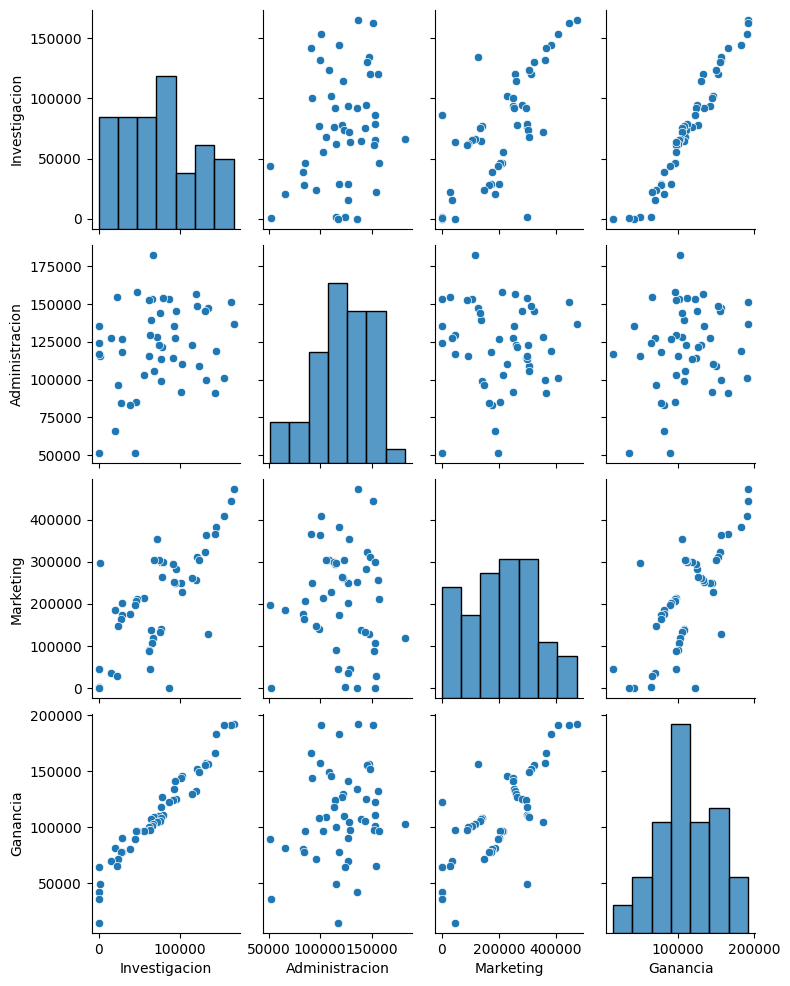

In [146]:
startups = pd.read_csv('datasets/50_Startups.csv')

sns.pairplot(data =startups, aspect= .8)

En base a éstos gráficos, si quisieramos predecir la ganancia mediante un modelo lineal utilizando una sola variable predictora, ¿Cuál variable utilizaría? Diseñar un experimento para verificar su respuesta.

In [148]:
startups.columns

Index(['Investigacion', 'Administracion', 'Marketing', 'Estado', 'Ganancia'], dtype='str')

El gráfico invita a usar 'Investigación' para predecir 'Ganancia'. Los valientes se atreverán a intentarlo con 'Marketing' . Yo soy valiente pero igual primero voy a ir con Investigación y después con Marketing para comparar ECMs

In [149]:
startups.isna().sum()

Investigacion     0
Administracion    0
Marketing         0
Estado            0
Ganancia          0
dtype: int64

No hay ningun nan!

In [151]:
startups_train, startups_test = train_test_split(startups,test_size=0.2,random_state=42)

In [ ]:
print(startups_train.shape[0],startups_test.shape[0])


40 10


,Investigacion,Administracion,Marketing,Estado,Ganancia
13,91992.39,135495.07,252664.93,California,134307.35
39,38558.51,82982.09,174999.30,California,81005.76
30,61994.48,115641.28,91131.24,Florida,99937.59
45,1000.23,124153.04,1903.93,New York,64926.08
17,94657.16,145077.58,282574.31,New York,125370.37
48,542.05,51743.15,0.00,New York,35673.41
26,75328.87,144135.98,134050.07,Florida,105733.54
25,64664.71,139553.16,137962.62,California,107404.34
32,63408.86,129219.61,46085.25,California,97427.84
19,86419.70,153514.11,0.00,New York,122776.86


In [177]:
modeloInv = linear_model.LinearRegression()
modeloInv.fit(startups[['Investigacion']],startups[['Ganancia']])

modeloMark = linear_model.LinearRegression()
modeloMark.fit(startups[['Marketing']],startups[['Ganancia']])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [179]:
#calculo ECM
ecmInv = mean_squared_error(startups[['Ganancia']],modeloInv.predict(startups[['Investigacion']]))
ecmMark = mean_squared_error(startups[['Ganancia']],modeloMark.predict(startups[['Marketing']]))
print("Usando Investigación:",ecmInv)
print("Usando Marketing", ecmMark)


Usando Investigación: 85120931.32706906
Usando Marketing 701870011.1971463


Dado los ECM estratosféricos que obtuve, voy a probar hacer los r2 a ver qué onda

In [180]:
r2_inv = r2_score(startups[['Ganancia']],modeloInv.predict(startups[['Investigacion']]))
r2_mark = r2_score(startups[['Ganancia']],modeloMark.predict(startups[['Marketing']]))

In [181]:
print("R2 Investigación: ",r2_inv)
print("R2 Marketing :", r2_mark)

R2 Investigación:  0.9465353160804393
R2 Marketing : 0.5591535746115515


Te dije que marketing era para valientes.

(b) En éste ejercicio ¿Considera que un modelo lineal multivariado ayudaría a predecir mejor la ganancia que el modelo lineal univariado del item anterior? Realizar un experimento para verificar su respuesta.

Ni a palo

In [ ]:
X=startups.drop(columns=['Ganancia','Estado']) #Nos quedamos con todas las columnas menos éstas 2
y=startups['Ganancia']
modelo2startups = linear_model.LinearRegression()
modelo2startups.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [192]:
print(r2_score(y,modelo2startups.predict(X)))

0.9507459940683246


El r2 subio un poquitito , solo 0.01. No vale la pena.

### **Ejercicio 3**

En el ejercicio 1 no tuvimos en cuenta el sexo del pingüino para predecir el peso, y puede ser una variable importante. Se quiere predecir ahora el peso de un pingüino usanddo como variables predictoras el largo de la aleta y el sexo del pingüino (utilizar el DataFrame sin datos faltantes, como vimos en el Ejercicio 1(a)).

In [203]:
penguins_limpia.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


(a) ¿Cuáles son los valores que toma la variable "sex"?¿Qué tipo de variable es: numérica o categórica, ordinal o nominal?¿Es una variable binaria?

In [204]:
penguins_limpia['sex'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Bueno efectivamente es una variable categórica, nominal, binaria.

(c) **Codificación de variables binarias**. Si utilizamos Formulaic para generar la matriz de datos e incluimos la variable sexo en el modelo, automáticamente va a crear una columna con el sexo codificado con 0's y 1's.

In [225]:
y, X = (
    Formula('body_mass_g ~ sex+ bill_length_mm + bill_depth_mm + flipper_length_mm+ species ')
    .get_model_matrix(penguins_limpia)
)

X

,Intercept,sex[T.Male],bill_length_mm,bill_depth_mm,flipper_length_mm,species[T.Chinstrap],species[T.Gentoo]
0,1.0,1,39.1,18.7,181.0,0,0
1,1.0,0,39.5,17.4,186.0,0,0
2,1.0,0,40.3,18.0,195.0,0,0
4,1.0,0,36.7,19.3,193.0,0,0
5,1.0,1,39.3,20.6,190.0,0,0
...,...,...,...,...,...,...,...
338,1.0,0,47.2,13.7,214.0,0,1
340,1.0,0,46.8,14.3,215.0,0,1
341,1.0,1,50.4,15.7,222.0,0,1
342,1.0,0,45.2,14.8,212.0,0,1


(d) Ajustar el modelo usando todos los datos disponibles. Reportar los coeficientes encontrados y calcular el error ECM ¿ Considera que agregar la variable "sex" mejoró el modelo?"

In [226]:
modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal. 
modelo.fit(X, y) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [227]:
# Calcular error cuadrático medio y R2
ecm = mean_squared_error(y, modelo.predict(X))
r2 = r2_score(y, modelo.predict(X))

print("ECM: ", ecm)
print("R2: ", r2)

ECM:  80827.7678932452
R2:  0.8749619600405569


Ahora recalculemos todo pero sin la variable "sex"

In [232]:
y, X = (
    Formula('body_mass_g ~ island + bill_length_mm + bill_depth_mm + flipper_length_mm+ species ')
    .get_model_matrix(penguins_limpia)
)

modelo2 = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal. 
modelo2.fit(X, y) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [233]:
ecm = mean_squared_error(y, modelo2.predict(X))
r2 = r2_score(y, modelo2.predict(X))

print("ECM: ", ecm)
print("R2: ", r2)

ECM:  96767.3565806685
R2:  0.8503039126988626


En éste caso, si bien el R2 sólo varió 0.02. El ECM (Que es lo que nos piden) mejoró sustancialmente. Entonces, creo que es correcto incluir la variable sex para predecir el peso.

(e) Realizar una visualización apropiada para ver los datos junto con las predicciones del modelo.